In [ ]:
# Import library yang dibutuhkan

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Memuat dataset Wine dari scikit-learn

wine = load_wine(as_frame=True)

X = wine.data
y = wine.target

print("Jumlah data:", X.shape[0])
print("Jumlah fitur:", X.shape[1])
print("Nama kelas:", wine.target_names)

display(X.head())

Jumlah data: 178
Jumlah fitur: 13
Nama kelas: ['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [ ]:
# Informasi dataset

print("Ukuran dataset:", X.shape)
print("\nNama fitur:")
for i, feature in enumerate(X.columns, start=1):
    print(f"{i}. {feature}")

print("\nDistribusi kelas:")
print(y.value_counts().sort_index())

Ukuran dataset: (178, 13)

Nama fitur:
1. alcohol
2. malic_acid
3. ash
4. alcalinity_of_ash
5. magnesium
6. total_phenols
7. flavanoids
8. nonflavanoid_phenols
9. proanthocyanins
10. color_intensity
11. hue
12. od280/od315_of_diluted_wines
13. proline

Distribusi kelas:
target
0    59
1    71
2    48
Name: count, dtype: int64


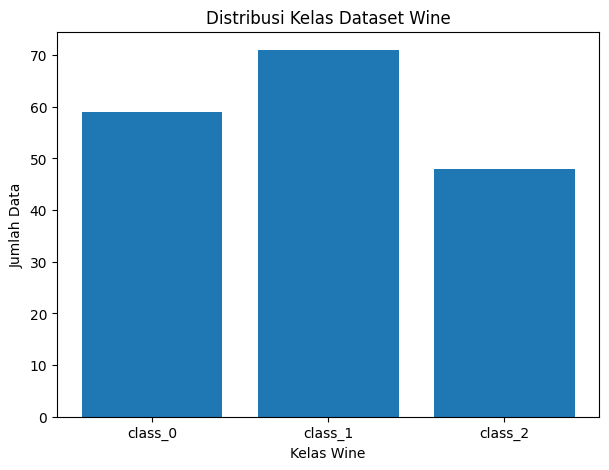

In [ ]:
# Visualisasi 1: Distribusi kelas

class_counts = y.value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(wine.target_names, class_counts)

plt.title("Distribusi Kelas Dataset Wine")
plt.xlabel("Kelas Wine")
plt.ylabel("Jumlah Data")
plt.show()

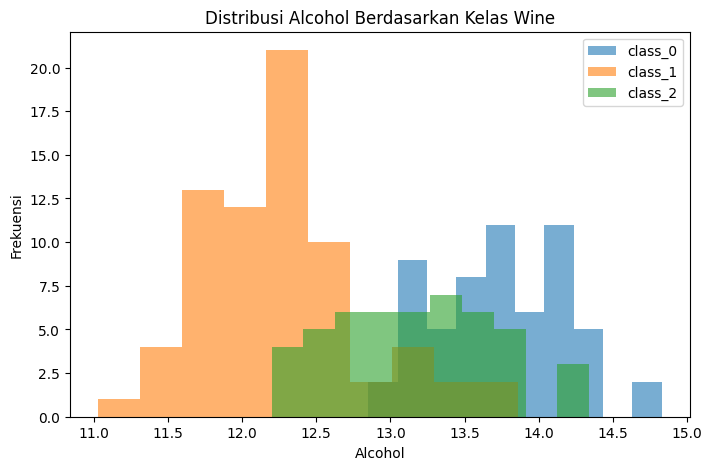

In [ ]:
# Visualisasi 2: Distribusi kandungan alcohol berdasarkan kelas

plt.figure(figsize=(8, 5))

for class_id in sorted(y.unique()):
    plt.hist(
        X.loc[y == class_id, "alcohol"],
        alpha=0.6,
        label=wine.target_names[class_id],
        bins=10
    )

plt.title("Distribusi Alcohol Berdasarkan Kelas Wine")
plt.xlabel("Alcohol")
plt.ylabel("Frekuensi")
plt.legend()
plt.show()

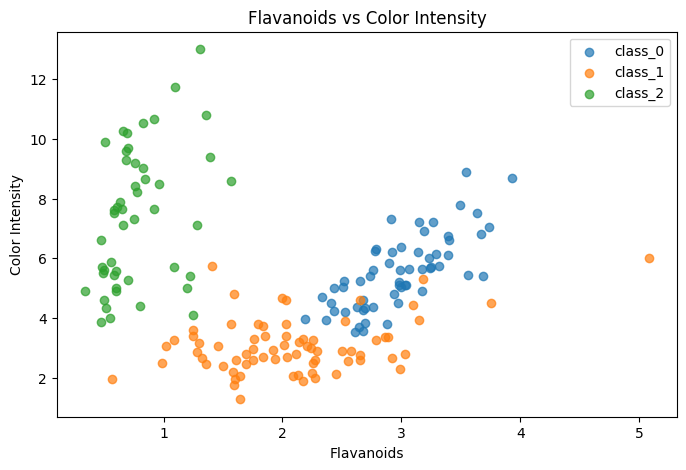

In [ ]:
# Visualisasi 3: Hubungan flavanoids dengan color_intensity

plt.figure(figsize=(8, 5))

for class_id in sorted(y.unique()):
    plt.scatter(
        X.loc[y == class_id, "flavanoids"],
        X.loc[y == class_id, "color_intensity"],
        label=wine.target_names[class_id],
        alpha=0.7
    )

plt.title("Flavanoids vs Color Intensity")
plt.xlabel("Flavanoids")
plt.ylabel("Color Intensity")
plt.legend()
plt.show()

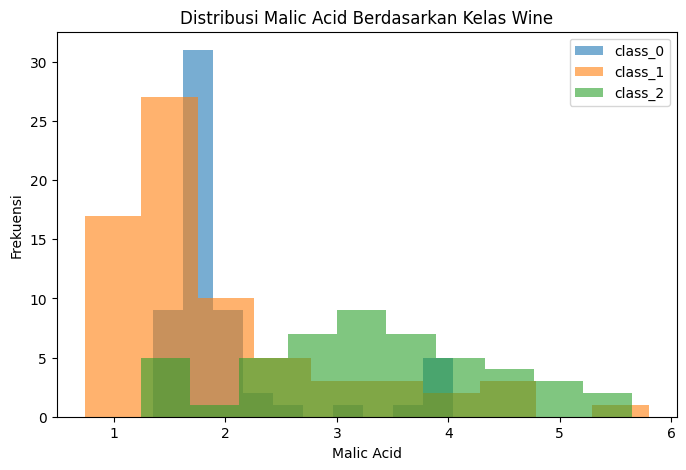

In [ ]:
# Visualisasi 4: Distribusi malic acid

plt.figure(figsize=(8, 5))

for class_id in sorted(y.unique()):
    plt.hist(
        X.loc[y == class_id, "malic_acid"],
        alpha=0.6,
        label=wine.target_names[class_id],
        bins=10
    )

plt.title("Distribusi Malic Acid Berdasarkan Kelas Wine")
plt.xlabel("Malic Acid")
plt.ylabel("Frekuensi")
plt.legend()
plt.show()

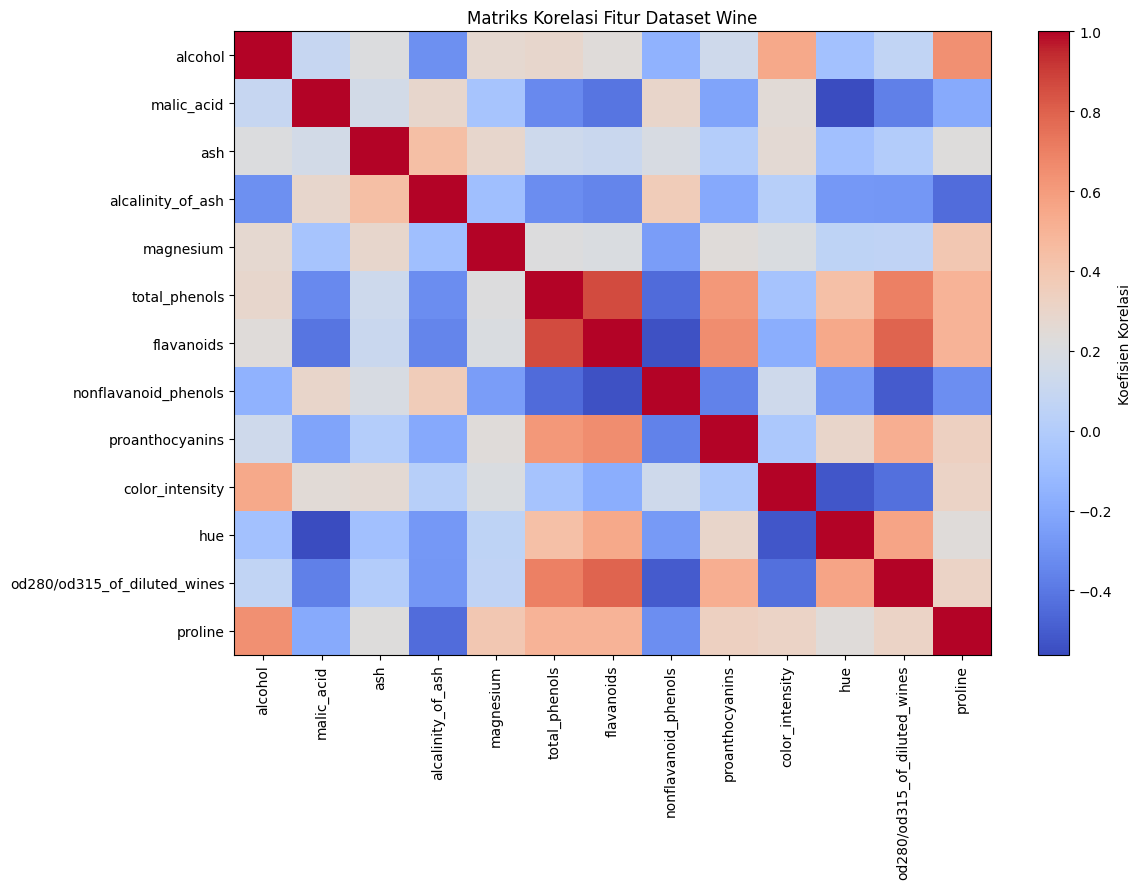

In [ ]:
# Visualisasi 5: Matriks korelasi

correlation = X.corr()

plt.figure(figsize=(12, 9))
plt.imshow(correlation, cmap="coolwarm", aspect="auto")

plt.colorbar(label="Koefisien Korelasi")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Matriks Korelasi Fitur Dataset Wine")
plt.tight_layout()
plt.show()

## T / E / P Dataset Wine

### T — Task (Tugas)
Tugas dari model adalah mengklasifikasikan wine ke dalam salah satu dari tiga kelas berdasarkan karakteristik kimia wine.

### E — Experience (Pengalaman)
Model belajar dari data Wine yang terdiri dari 178 sampel wine dengan 13 fitur karakteristik kimia dan label kelas wine.

### P — Performance (Penilaian)
Performa model dinilai menggunakan akurasi dan classification report pada data testing yang belum digunakan saat proses pelatihan.

In [ ]:
# Membagi dataset menjadi data training dan testing
# 70% untuk training dan 30% untuk testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Jumlah data training:", len(X_train))
print("Jumlah data testing :", len(X_test))

Jumlah data training: 124
Jumlah data testing : 54


In [ ]:
# Membuat model K-Nearest Neighbors

model = KNeighborsClassifier(n_neighbors=3)

# Melatih model menggunakan data training
model.fit(X_train, y_train)

print("Model berhasil dilatih.")

Model berhasil dilatih.


In [ ]:
# Melakukan prediksi terhadap data testing

y_pred = model.predict(X_test)

print("Hasil prediksi:")
print(y_pred)

Hasil prediksi:
[0 1 0 0 0 0 1 1 1 1 1 2 1 1 0 2 1 0 0 1 1 0 1 1 2 2 0 2 0 2 2 1 2 1 2 2 0
 1 2 0 1 0 0 0 0 1 1 0 2 0 1 1 2 0]


In [ ]:
# Menghitung akurasi model

accuracy = accuracy_score(y_test, y_pred)

print(f"Akurasi model: {accuracy:.2%}")

Akurasi model: 68.52%


In [ ]:
# Menampilkan classification report

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=wine.target_names
    )
)

Classification Report:
              precision    recall  f1-score   support

     class_0       0.85      0.94      0.89        18
     class_1       0.67      0.67      0.67        21
     class_2       0.46      0.40      0.43        15

    accuracy                           0.69        54
   macro avg       0.66      0.67      0.66        54
weighted avg       0.67      0.69      0.68        54



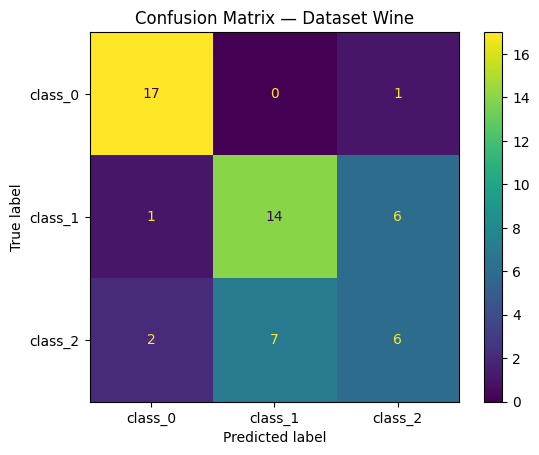

In [ ]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=wine.target_names
)

disp.plot()
plt.title("Confusion Matrix — Dataset Wine")
plt.show()